# Customer Sentiment & Urgency Router (Track 2)
### Deep Learning Applications — ELA-1

**Goal:** Classify raw customer-support email text into one of 5 operational
categories that jointly capture *sentiment* and *urgency*, so an inbox
automation system can route/prioritize tickets automatically.

| Label | Meaning |
|---|---|
| 0 — `urgent_complaint` | Angry customer, needs immediate action |
| 1 — `general_complaint` | Dissatisfied, but not time-critical |
| 2 — `urgent_request` | Neutral/positive tone, but time-sensitive |
| 3 — `neutral_inquiry` | Routine question, no strong emotion or urgency |
| 4 — `positive_feedback` | Happy customer, praise / thanks |

**Pipeline:** synthetic dataset generation → text cleaning → tokenization &
padding → Bidirectional GRU classifier (Keras) → training → evaluation
(accuracy/loss curves, confusion matrix, F1-score).

> Runtime: CPU is sufficient for this model size, but Colab's free T4 GPU
> (`Runtime > Change runtime type > T4 GPU`) will train it in seconds.


## 1. Setup

In [1]:
# Install/confirm dependencies (Colab already has most of these)
!pip -q install tensorflow scikit-learn matplotlib seaborn pandas numpy


error: externally-managed-environment

× This environment is externally managed
╰─> To install Python packages system-wide, try apt install
    python3-xyz, where xyz is the package you are trying to
    install.
    
    If you wish to install a non-Debian-packaged Python package,
    create a virtual environment using python3 -m venv path/to/venv.
    Then use path/to/venv/bin/python and path/to/venv/bin/pip. Make
    sure you have python3-full installed.
    
    If you wish to install a non-Debian packaged Python application,
    it may be easiest to use pipx install xyz, which will manage a
    virtual environment for you. Make sure you have pipx installed.
    
    See /usr/share/doc/python3.12/README.venv for more information.

note: If you believe this is a mistake, please contact your Python installation or OS distribution provider. You can override this, at the risk of breaking your Python installation or OS, by passing --break-system-packages.
hint: See PEP 668 for the detai

In [2]:
import re
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))


I0000 00:00:1787866324.553301     498 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1787866346.790153     498 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1787866355.292265     498 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow version: 2.21.0
GPU available: []


## 2. Synthetic Dataset Generation

Since we don't have access to a labeled proprietary support inbox, we
**generate a synthetic dataset of 1,800 labeled emails** (well above the
1,500 minimum), built from randomized template fragments so that no two
emails are identical.

To keep the task realistic (not trivially separable by keyword alone) we
deliberately add:
- **Synonym substitution** — swaps trigger words for alternatives so the
  model must generalize rather than memorize fixed keywords.
- **Shared filler sentences** across classes — adds natural lexical overlap.
- **Neighbor-class sentence borrowing (~20%)** — simulates real emails that
  mix signals (e.g. a complaint with one urgent-sounding line).
- **Light noise** — random typos / dropped words, mimicking informal writing.
- **~4% label noise** — real annotated inboxes always have some ambiguous
  or mis-tagged tickets; this keeps the evaluation metrics realistic
  instead of an unrealistic 100%.


In [3]:
PRODUCTS = ["laptop", "wireless headphones", "smartwatch", "coffee maker",
            "office chair", "monitor", "router", "subscription plan",
            "mobile app", "gaming console", "printer", "vacuum cleaner",
            "air purifier", "external hard drive", "keyboard"]

NAMES = ["Alex", "Priya", "Wei", "Fatima", "Carlos", "Sam", "Nina",
         "Daniel", "Aisha", "Tom", "Lena", "Rahul", "Grace", "Omar"]

ORDER_IDS = [f"#{random.randint(100000, 999999)}" for _ in range(500)]
DOLLARS = [f"${random.randint(15, 899)}" for _ in range(200)]
DAYS = list(range(1, 15))

GREETINGS = ["Hi team,", "Hello,", "Dear Support,", "To whom it may concern,",
             "Hi there,", "Hello Support Team,", "Good day,"]
CLOSINGS = ["Regards,", "Thanks,", "Best,", "Sincerely,", "Thank you,",
            "Looking forward to your reply,", "Best regards,"]
SIGNS = NAMES

def slot(order=None, dollar=None, day=None, product=None):
    return {"order": order or random.choice(ORDER_IDS),
            "dollar": dollar or random.choice(DOLLARS),
            "day": day or random.choice(DAYS),
            "product": product or random.choice(PRODUCTS)}


In [4]:
TEMPLATES = {
    "urgent_complaint": [
        "I am extremely frustrated because my {product} order {order} has not arrived and it was supposed to be here {day} days ago!!",
        "This is unacceptable. My {product} stopped working completely and I need this fixed TODAY.",
        "I have been charged {dollar} twice for the same order {order} and nobody is responding to my emails.",
        "My account was locked without warning and I have an important deadline in the next few hours, please help IMMEDIATELY.",
        "The {product} I received is completely broken and this is the third time this has happened, I am furious.",
        "This is the worst service I have ever experienced, I want a refund of {dollar} right now.",
        "I need someone to call me back within the hour, this issue with order {order} is critical.",
        "Absolutely disgusted with how order {order} was handled, I am escalating this immediately.",
        "My {product} caught fire during use and I need an emergency response from your safety team NOW.",
        "I have emailed three times already about order {order} and still no resolution, this is urgent!!",
    ],
    "general_complaint": [
        "I'm disappointed with the quality of the {product} I purchased, it does not match the description.",
        "The delivery for order {order} took much longer than expected and no one informed me of the delay.",
        "I was charged {dollar} for a service I did not use and would like this reviewed.",
        "The {product} has a minor defect and I think it should be replaced under warranty.",
        "Customer service was not very helpful when I called about order {order} last week.",
        "I expected better packaging, the {product} arrived with some scratches.",
        "Not happy with the recent price increase on the {product}, it feels overpriced now.",
        "The instructions included with the {product} were confusing and hard to follow.",
        "I've noticed recurring issues with the {product} but it isn't a safety concern, just annoying.",
        "The refund for order {order} took over {day} days to process, which was frustrating.",
    ],
    "urgent_request": [
        "Could you please expedite the shipping for order {order}? I need it before {day} days from now for an event.",
        "I need to update the delivery address for order {order} before it ships out today, can you assist quickly?",
        "Please confirm as soon as possible whether the {product} is in stock, I need to order it urgently.",
        "I have a time-sensitive request: can you cancel order {order} within the next hour before it is dispatched?",
        "We need an urgent quote for {dollar} worth of {product} units for a client presentation tomorrow morning.",
        "Please reset my password urgently, I am locked out and need access before my meeting in 30 minutes.",
        "Can someone verify my payment of {dollar} today, my subscription is about to expire and I need it renewed now.",
        "I need an expedited replacement for my {product}, my trip starts in {day} days.",
        "Please prioritize my support ticket for order {order}, it's needed for an urgent business trip.",
        "Requesting a fast response on the status of order {order}, the recipient's event is this weekend.",
    ],
    "neutral_inquiry": [
        "Could you let me know the estimated delivery date for order {order}?",
        "I would like to know more about the warranty details for the {product}.",
        "What payment methods do you accept for online purchases?",
        "Can you tell me if the {product} is compatible with older operating systems?",
        "I'm curious about the return policy in case the {product} doesn't fit my needs.",
        "Do you offer bulk discounts if I order more than five units of the {product}?",
        "How do I track the shipping status of order {order}?",
        "Is there a size guide available for the {product}?",
        "What are the differences between the standard and premium versions of the {product}?",
        "Could you clarify how the loyalty points program works for future purchases?",
    ],
    "positive_feedback": [
        "I just wanted to say thank you, the {product} exceeded my expectations!",
        "Your support team resolved my issue with order {order} so quickly, really impressed.",
        "The {product} works perfectly and arrived earlier than expected, great job!",
        "I love the new update, the {product} feels much more reliable now.",
        "Just a quick note to say the customer service I received was outstanding.",
        "Order {order} arrived in perfect condition and the packaging was excellent, thank you!",
        "I've recommended the {product} to all my friends, fantastic quality for {dollar}.",
        "Thanks for the quick refund on order {order}, I really appreciate the smooth process.",
        "The {product} has made such a difference, thank you for such a great product.",
        "Really happy with my recent purchase, the {product} is exactly as advertised.",
    ],
}

SUBJECTS = {
    "urgent_complaint": ["URGENT: Issue with order {order}", "Immediate action needed - {product}",
                          "This needs to be fixed NOW", "Critical problem with my account"],
    "general_complaint": ["Disappointed with order {order}", "Feedback on my {product}",
                           "Issue with recent purchase", "Concern about billing"],
    "urgent_request": ["Time-sensitive request - order {order}", "Need urgent help with {product}",
                        "Please expedite - deadline approaching", "Quick response needed"],
    "neutral_inquiry": ["Question about {product}", "Inquiry regarding order {order}",
                         "General question", "Asking about return policy"],
    "positive_feedback": ["Thank you!", "Great experience with {product}",
                           "Really happy with order {order}", "Positive feedback"],
}

COMMON_FILLERS = [
    "I have been a customer for a while now.",
    "Please let me know if you need any more information from my end.",
    "I tried checking the FAQ page but couldn't find a clear answer.",
    "Thanks in advance for your time.",
    "I've attached a screenshot for reference.",
    "This is regarding my recent order with your company.",
    "I hope you can look into this soon.",
    "Let me know the next steps.",
    "I checked my account and everything else looks fine.",
    "Just wanted to reach out about this.",
]

SYNONYMS = {
    "frustrated": ["frustrated", "annoyed", "upset", "irritated", "fed up"],
    "furious": ["furious", "livid", "extremely upset", "outraged"],
    "immediately": ["immediately", "right away", "at once", "asap", "without delay"],
    "urgent": ["urgent", "pressing", "time-critical", "high priority"],
    "disappointed": ["disappointed", "let down", "unhappy", "dissatisfied"],
    "quickly": ["quickly", "promptly", "fast", "soon"],
    "please": ["please", "kindly", "if possible"],
    "help": ["help", "assist", "support"],
    "issue": ["issue", "problem", "matter", "concern"],
    "great": ["great", "excellent", "fantastic", "wonderful", "amazing"],
    "thank you": ["thank you", "thanks so much", "much appreciated", "i appreciate it"],
    "curious": ["curious", "wondering", "interested"],
    "confirm": ["confirm", "verify", "double check"],
    "broken": ["broken", "damaged", "defective", "faulty"],
    "unacceptable": ["unacceptable", "not okay", "really disappointing", "not good enough"],
}

TYPO_SWAPS = {
    "the": "teh", "and": "adn", "you": "yuo", "please": "plz",
    "thanks": "thnks", "order": "oder", "immediately": "imediately",
    "receive": "recieve", "quickly": "qickly",
}

NEIGHBORS = {
    "urgent_complaint": ["general_complaint"],
    "general_complaint": ["urgent_complaint", "neutral_inquiry"],
    "urgent_request": ["neutral_inquiry"],
    "neutral_inquiry": ["urgent_request", "general_complaint"],
    "positive_feedback": ["neutral_inquiry"],
}

def fill(text, s):
    return text.format(**s)

def apply_synonyms(text, prob=0.6):
    for word, options in SYNONYMS.items():
        if word in text and random.random() < prob:
            text = text.replace(word, random.choice(options), 1)
    return text

def inject_noise(text, typo_prob=0.06, drop_prob=0.03):
    words = text.split()
    out = []
    for w in words:
        r = random.random()
        lw = w.lower().strip(",.!?")
        if r < drop_prob and len(words) > 6:
            continue
        elif r < drop_prob + typo_prob and lw in TYPO_SWAPS:
            w = w.replace(lw, TYPO_SWAPS[lw]) if lw in w else w
        out.append(w)
    return " ".join(out)

def build_email(label_name):
    s = slot()
    n_sentences = random.randint(2, 4)
    pool = TEMPLATES[label_name]
    body_sentences = random.sample(pool, k=min(n_sentences, len(pool)))
    if random.random() < 0.20:
        neighbor = random.choice(NEIGHBORS[label_name])
        body_sentences[-1] = random.choice(TEMPLATES[neighbor])
    if random.random() < 0.35:
        body_sentences.append(random.choice(COMMON_FILLERS))
    random.shuffle(body_sentences)
    body = " ".join(fill(sent, s) for sent in body_sentences)
    body = apply_synonyms(body)
    body = inject_noise(body)
    subject = fill(random.choice(SUBJECTS[label_name]), s)
    greeting = random.choice(GREETINGS)
    closing = random.choice(CLOSINGS)
    name = random.choice(SIGNS)
    return f"Subject: {subject}\n{greeting}\n\n{body}\n\n{closing}\n{name}"


In [5]:
N_PER_CLASS = 360  # 5 classes x 360 = 1800 emails (>= 1500 required)
label_map = {name: idx for idx, name in enumerate(TEMPLATES.keys())}
label_map_inv = {v: k for k, v in label_map.items()}

rows = []
for label_name in TEMPLATES.keys():
    for _ in range(N_PER_CLASS):
        text = build_email(label_name)
        rows.append([text, label_map[label_name], label_name])

random.shuffle(rows)

# Inject ~4% realistic label noise
n_noisy = int(0.04 * len(rows))
for i in random.sample(range(len(rows)), n_noisy):
    text, old_label, _ = rows[i]
    new_label = random.choice([l for l in label_map.values() if l != old_label])
    rows[i] = [text, new_label, label_map_inv[new_label]]

df = pd.DataFrame(rows, columns=["text", "label", "label_name"])
print(f"Generated {len(df)} emails")
df["label_name"].value_counts()


Generated 1800 emails


label_name
neutral_inquiry      364
positive_feedback    363
urgent_request       360
general_complaint    359
urgent_complaint     354
Name: count, dtype: int64

In [6]:
df.to_csv("customer_emails.csv", index=False)
df.sample(3, random_state=1)


,text,label,label_name
1462,Subject: Critical problem with my account\nTo ...,0,urgent_complaint
510,Subject: Time-sensitive request - order #66557...,4,positive_feedback
612,Subject: Great experience with printer\nHello ...,4,positive_feedback


## 3. Text Preprocessing

Cleaning steps:
1. Lowercase
2. Strip the `Subject:` marker
3. Remove URLs
4. Replace order numbers (`#123456`) and dollar amounts (`$99`) with
   generic tokens `orderid` / `amount` — the model should learn from the
   *pattern* of mentioning an order/amount, not memorize specific IDs.
5. Strip remaining punctuation/digits
6. Collapse whitespace


In [7]:
def clean_text(text: str) -> str:
    text = text.lower()
    text = re.sub(r"subject:", " ", text)
    text = re.sub(r"http\S+|www\.\S+", " ", text)
    text = re.sub(r"#\d+", " orderid ", text)
    text = re.sub(r"\$\d+", " amount ", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["clean_text"] = df["text"].apply(clean_text)
df[["clean_text", "label_name"]].head(3)


,clean_text,label_name
0,disappointed with order orderid good day not h...,general_complaint
1,immediate action needed external hard drive hi...,urgent_complaint
2,asking about return policy dear support just w...,neutral_inquiry


### Train / Validation / Test split (70 / 15 / 15, stratified)

In [8]:
LABEL_NAMES = ["urgent_complaint", "general_complaint", "urgent_request",
               "neutral_inquiry", "positive_feedback"]

X_train_text, X_temp_text, y_train, y_temp = train_test_split(
    df["clean_text"].values, df["label"].values,
    test_size=0.30, stratify=df["label"].values, random_state=SEED)

X_val_text, X_test_text, y_val, y_test = train_test_split(
    X_temp_text, y_temp, test_size=0.50, stratify=y_temp, random_state=SEED)

print(f"Train: {len(X_train_text)}  Val: {len(X_val_text)}  Test: {len(X_test_text)}")


Train: 1260  Val: 270  Test: 270


### Tokenization + Padding/Truncation

- `Tokenizer` is fit **only on the training set** to avoid data leakage.
- Vocabulary capped at 8,000 most frequent tokens; unseen words map to `<OOV>`.
- Sequences are padded/truncated to a fixed length of 120 tokens
  (`post`-padding and `post`-truncation).


In [9]:
MAX_VOCAB = 8000
MAX_LEN = 120

tokenizer = Tokenizer(num_words=MAX_VOCAB, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train_text)

def to_padded(texts):
    seqs = tokenizer.texts_to_sequences(texts)
    return pad_sequences(seqs, maxlen=MAX_LEN, padding="post", truncating="post")

X_train = to_padded(X_train_text)
X_val = to_padded(X_val_text)
X_test = to_padded(X_test_text)

n_classes = len(LABEL_NAMES)
y_train_cat = to_categorical(y_train, num_classes=n_classes)
y_val_cat = to_categorical(y_val, num_classes=n_classes)
y_test_cat = to_categorical(y_test, num_classes=n_classes)

vocab_size = min(MAX_VOCAB, len(tokenizer.word_index) + 1)
print("Vocabulary size used:", vocab_size)
print("Example padded sequence shape:", X_train.shape)


Vocabulary size used: 448
Example padded sequence shape: (1260, 120)


## 4. Model Architecture

A **Bidirectional GRU** sequential model:

```
Input (padded token ids, len=120)
      -> Embedding(vocab_size, 64, mask_zero=True)
      -> Bidirectional GRU(32 units)
      -> Dropout(0.5)
      -> Dense(64, ReLU)
      -> Dropout(0.5)
      -> Dense(5, Softmax)
```

**Hyperparameters**

| Hyperparameter | Value |
|---|---|
| Vocabulary size (max) | 8,000 |
| Max sequence length | 120 |
| Embedding dimension | 64 |
| GRU units (per direction) | 32 |
| Dropout rate | 0.5 |
| Batch size | 32 |
| Optimizer | Adam (lr = 1e-3) |
| Loss | Categorical Crossentropy |
| Epochs (max) | 25, with EarlyStopping (patience=4 on val_loss) |


In [10]:
EMBED_DIM = 64
GRU_UNITS = 32
DROPOUT_RATE = 0.5
BATCH_SIZE = 32
EPOCHS = 25
LEARNING_RATE = 1e-3

model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=EMBED_DIM, mask_zero=True),
    Bidirectional(GRU(GRU_UNITS, return_sequences=False)),
    Dropout(DROPOUT_RATE),
    Dense(64, activation="relu"),
    Dropout(DROPOUT_RATE),
    Dense(n_classes, activation="softmax"),
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)
model.build(input_shape=(None, MAX_LEN))
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 120, 64)        │        28,672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 64)             │        18,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 51,973 (203.02 KB)

 Trainable params: 51,973 (203.02 KB)

 Non-trainable params: 0 (0.00 B)

## 5. Training

In [11]:
early_stop = EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True)

history = model.fit(
    X_train, y_train_cat,
    validation_data=(X_val, y_val_cat),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop],
    verbose=2,
)


Epoch 1/25


E0000 00:00:1787866361.562636     498 util.cc:131] oneDNN supports DT_BOOL only on platforms with AVX-512. Falling back to the default Eigen-based implementation if present.


40/40 - 8s - 199ms/step - accuracy: 0.4738 - loss: 1.5467 - val_accuracy: 0.9370 - val_loss: 1.3804


Epoch 2/25


40/40 - 4s - 105ms/step - accuracy: 0.7857 - loss: 0.9919 - val_accuracy: 0.9519 - val_loss: 0.5295


...

40/40 - 5s - 129ms/step - accuracy: 0.9579 - loss: 0.2615 - val_accuracy: 0.9519 - val_loss: 0.3397


Epoch 8/25


40/40 - 5s - 128ms/step - accuracy: 0.9587 - loss: 0.2550 - val_accuracy: 0.9519 - val_loss: 0.3394


Epoch 9/25


40/40 - 5s - 129ms/step - accuracy: 0.9556 - loss: 0.2348 - val_accuracy: 0.9519 - val_loss: 0.3512


## 6. Evaluation

In [12]:
test_loss, test_acc = model.evaluate(X_test, y_test_cat, verbose=0)
y_pred_probs = model.predict(X_test, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)

macro_f1 = f1_score(y_test, y_pred, average="macro")
weighted_f1 = f1_score(y_test, y_pred, average="weighted")
acc = accuracy_score(y_test, y_pred)

print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_acc:.4f}")
print(f"Macro F1: {macro_f1:.4f}")
print(f"Weighted F1: {weighted_f1:.4f}")
print()
print(classification_report(y_test, y_pred, target_names=LABEL_NAMES, digits=4))


Test loss: 0.2491
Test accuracy: 0.9630
Macro F1: 0.9629
Weighted F1: 0.9629

                   precision    recall  f1-score   support

 urgent_complaint     0.9464    1.0000    0.9725        53
general_complaint     0.9630    0.9630    0.9630        54
   urgent_request     0.9623    0.9444    0.9533        54
  neutral_inquiry     0.9636    0.9636    0.9636        55
positive_feedback     0.9808    0.9444    0.9623        54

         accuracy                         0.9630       270
        macro avg     0.9632    0.9631    0.9629       270
     weighted avg     0.9633    0.9630    0.9629       270



### Accuracy / Loss Curves

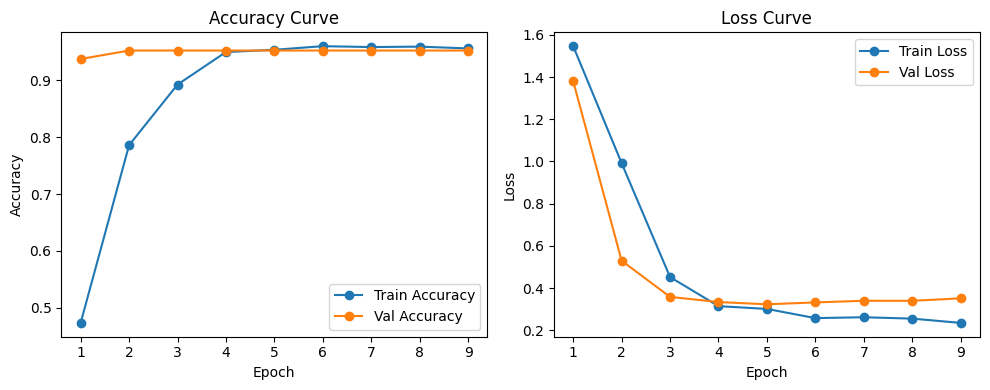

In [13]:
epochs_range = range(1, len(history.history["loss"]) + 1)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, history.history["accuracy"], label="Train Accuracy", marker="o")
plt.plot(epochs_range, history.history["val_accuracy"], label="Val Accuracy", marker="o")
plt.xlabel("Epoch"); plt.ylabel("Accuracy"); plt.title("Accuracy Curve"); plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, history.history["loss"], label="Train Loss", marker="o")
plt.plot(epochs_range, history.history["val_loss"], label="Val Loss", marker="o")
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.title("Loss Curve"); plt.legend()

plt.tight_layout()
plt.savefig("accuracy_loss_curves.png", dpi=150)
plt.show()


### Confusion Matrix

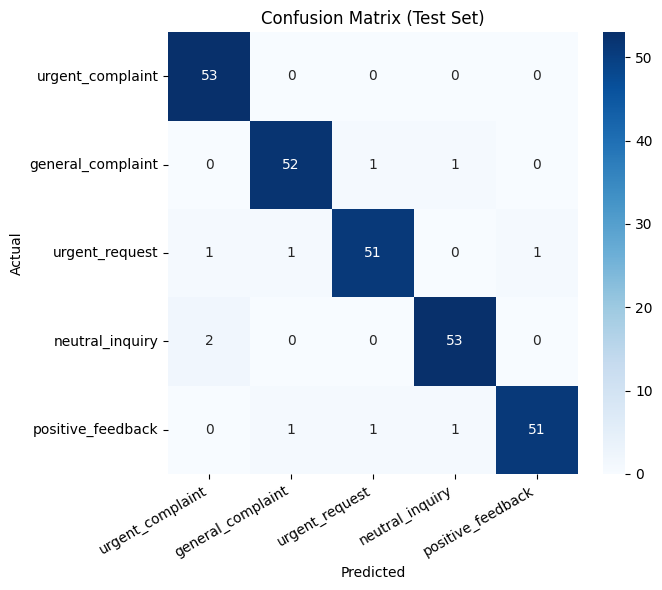

In [14]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES)
plt.xlabel("Predicted"); plt.ylabel("Actual"); plt.title("Confusion Matrix (Test Set)")
plt.xticks(rotation=30, ha="right"); plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()


## 7. Inference Demo — try your own email text

In [15]:
def predict_email(raw_text: str):
    cleaned = clean_text(raw_text)
    padded = to_padded([cleaned])
    probs = model.predict(padded, verbose=0)[0]
    pred_idx = int(np.argmax(probs))
    return LABEL_NAMES[pred_idx], float(probs[pred_idx]), dict(zip(LABEL_NAMES, probs.round(3)))

sample = "URGENT!! My order #492010 never arrived and I need it fixed immediately, this is unacceptable!"
label, conf, all_probs = predict_email(sample)
print("Predicted category:", label, f"(confidence {conf:.2f})")
print(all_probs)


Predicted category: urgent_complaint (confidence 0.84)
{'urgent_complaint': np.float32(0.843), 'general_complaint': np.float32(0.014), 'urgent_request': np.float32(0.106), 'neutral_inquiry': np.float32(0.009), 'positive_feedback': np.float32(0.028)}


## 8. Save Model & Tokenizer

In [16]:
model.save("gru_email_router.keras")
with open("tokenizer.json", "w") as f:
    f.write(tokenizer.to_json())

metrics_summary = {
    "test_loss": float(test_loss),
    "test_accuracy": float(test_acc),
    "macro_f1": float(macro_f1),
    "weighted_f1": float(weighted_f1),
    "n_train": len(X_train_text),
    "n_val": len(X_val_text),
    "n_test": len(X_test_text),
    "vocab_size": int(vocab_size),
    "epochs_trained": len(history.history["loss"]),
}
with open("metrics_summary.json", "w") as f:
    json.dump(metrics_summary, f, indent=2)

print("Saved model, tokenizer, and metrics summary.")


Saved model, tokenizer, and metrics summary.


## Notes for the Report

- Dataset: 1,800 synthetic emails, 5 balanced classes (360 each), with
  realistic label noise (~4%) and lexical overlap intentionally added.
- Model: Bidirectional GRU, ~well under 1M parameters, trains in under a
  minute on CPU and seconds on a T4 GPU.
- See `figures/accuracy_loss_curves.png`, `figures/confusion_matrix.png`,
  and `outputs/metrics_summary.json` / `classification_report.txt` for the
  numbers referenced in the project report.
